In [2]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import matplotlib.pyplot as plt

In [3]:
hourly_df = pd.read_csv(
    "../data/processed/hourly_energy.csv"
)

meter_df = hourly_df[
    hourly_df["meter"] == "BR02"
].copy()

meter_df["x_Timestamp"] = pd.to_datetime(
    meter_df["x_Timestamp"]
)

meter_df = meter_df.sort_values(
    "x_Timestamp"
)

In [4]:
data = meter_df[
    ["t_kWh"]
].values

In [5]:
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(
    data
)

In [6]:
X = []
y = []

window = 24

for i in range(window, len(data_scaled)):
    X.append(data_scaled[i-window:i])
    y.append(data_scaled[i])

X = np.array(X)
y = np.array(y)

In [7]:
split = int(
    len(X) * 0.9
)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [8]:
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
)

y_test = torch.tensor(
    y_test,
    dtype=torch.float32
)

In [9]:
# Train-test split
split = int(len(X) * 0.9)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [10]:
# Reshape target
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

In [11]:
# Convert to tensors
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
)

y_test = torch.tensor(
    y_test,
    dtype=torch.float32
)

In [12]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

torch.Size([13089, 24, 1])
torch.Size([13089, 1])
torch.Size([1455, 24, 1])
torch.Size([1455, 1])


In [13]:
class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(
            128,
            1
        )

    def forward(self, x):

        out, _ = self.lstm(x)

        out = self.fc(
            out[:, -1, :]
        )

        return out

In [14]:
model = LSTMModel()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [15]:
print(X.shape)

(14544, 24, 1)


In [16]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [17]:
print(model)

LSTMModel(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [18]:
epochs = 30

for epoch in range(epochs):

    model.train()

    epoch_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Loss: {epoch_loss/len(train_loader):.6f}"
        )

Epoch [5/30], Loss: 0.008853
Epoch [10/30], Loss: 0.008763
Epoch [15/30], Loss: 0.008357
Epoch [20/30], Loss: 0.008154
Epoch [25/30], Loss: 0.007990
Epoch [30/30], Loss: 0.007891


In [19]:
model.eval()

with torch.no_grad():

    predictions = model(X_test)

predictions = predictions.numpy()
y_test_np = y_test.numpy()

In [20]:
predictions = scaler.inverse_transform(
    predictions
)

actual = scaler.inverse_transform(
    y_test_np
)

In [21]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(
    actual,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.0393960103392601
RMSE: 0.07417269896782279


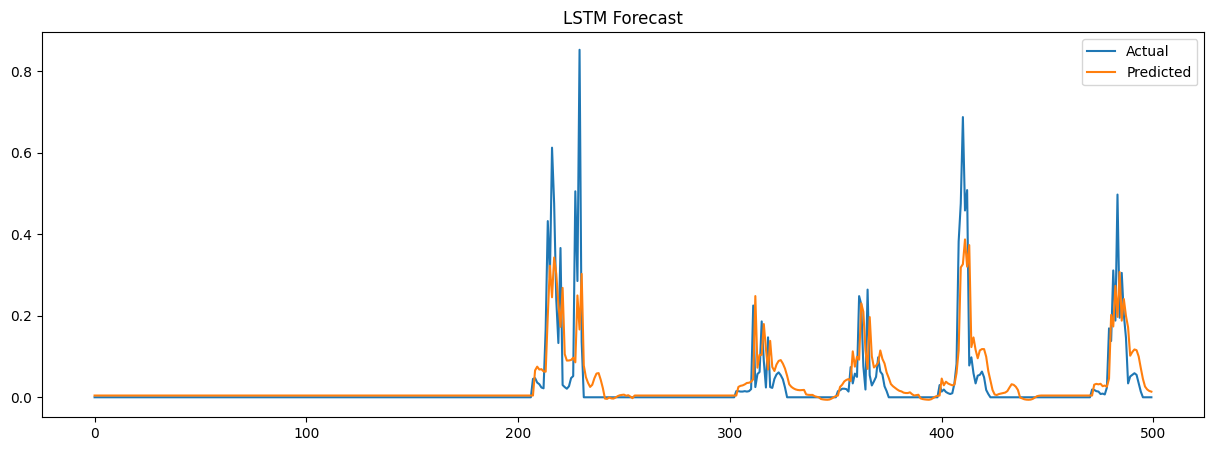

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    actual[:500],
    label="Actual"
)

plt.plot(
    predictions[:500],
    label="Predicted"
)

plt.legend()

plt.title("LSTM Forecast")

plt.show()

In [23]:
results = pd.DataFrame({
    "Model": ["Prophet", "SARIMA", "LSTM"],
    "MAE": [0.2181, 0.0874, 0.0380],
    "RMSE": [0.2685, 0.1360, 0.0739]
})

results.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print(results)

     Model     MAE    RMSE
0  Prophet  0.2181  0.2685
1   SARIMA  0.0874  0.1360
2     LSTM  0.0380  0.0739


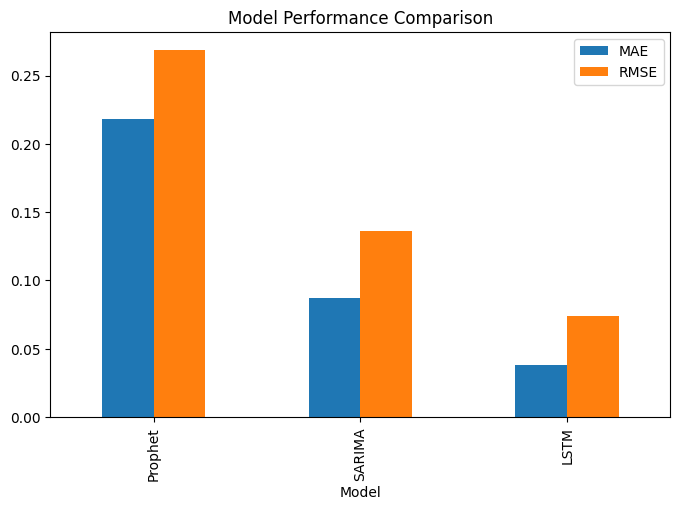

In [24]:
import matplotlib.pyplot as plt

results.plot(
    x="Model",
    y=["MAE", "RMSE"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")

plt.savefig(
    "../reports/figures/model_comparison.png"
)

plt.show()

In [26]:
pred_df = pd.DataFrame({
    "Actual": actual.flatten(),
    "Predicted": predictions.flatten()
})

pred_df.to_csv(
    "../reports/lstm_predictions.csv",
    index=False
)

In [27]:
pred_df.head()

,Actual,Predicted
0,0.0,0.004313
1,0.0,0.004313
2,0.0,0.004313
3,0.0,0.004313
4,0.0,0.004313
